In [1]:
#Here I am Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
#Here I am reading the dataset
salary_data = pd.read_csv('D:/TuteDude/GenAI/MachineLearning/Assignment_15/Salary.csv')
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
#Here I am checking for any missing values in my data or not
print("Missing_Values", salary_data.isnull().sum())
print("Data Desc", salary_data.describe())


Missing_Values YearsExperience    0
Salary             0
dtype: int64
Data Desc        YearsExperience         Salary
count        35.000000      35.000000
mean          6.308571   83945.600000
std           3.618610   32162.673003
min           1.100000   37731.000000
25%           3.450000   57019.000000
50%           5.300000   81363.000000
75%           9.250000  113223.500000
max          13.500000  139465.000000


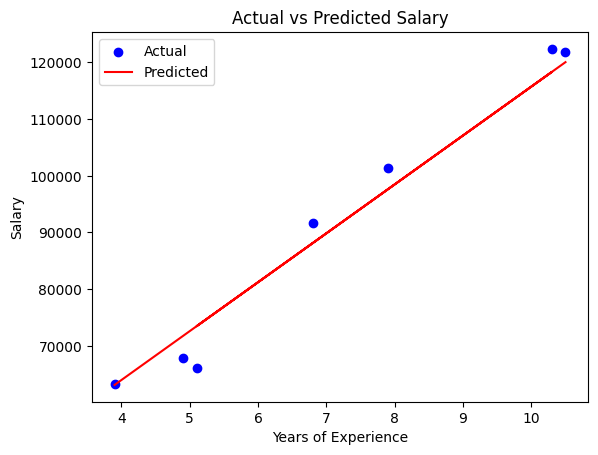

In [4]:
#Task - 1
#now I am splitting the data into training and testing data
X = salary_data[['YearsExperience']]
y = salary_data['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
#Now I am creating the model and fitting my model with my training Data 
model = LinearRegression()
model.fit(X_train, y_train)
#now i am making the predictions on my test data
y_pred = model.predict(X_test)
#now i am plotting the graphs between the actual vs predicted values
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

In [5]:
#Task -2 
#now I am calculating the mean squared error, mean absolute error and r2 score for my model
mse_score = mean_squared_error(y_test, y_pred)
r2_score_value = r2_score(y_test, y_pred)
mae_score = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse_score)
print("R2 Score:", r2_score_value)
print("Mean Absolute Error:", mae_score)

Mean Squared Error: 16561691.220974546
R2 Score: 0.9708090245443415
Mean Absolute Error: 3500.419123800644


In [6]:
#Task - 3
#Logistic Regression
#Now I am reading the new data set for my logistic regression model
cancer_data = pd.read_csv('D:/TuteDude/GenAI/MachineLearning/Assignment_15/breast_cancer.csv')
print(cancer_data.head())
print("Missing Values:",cancer_data.isnull().sum())
print(cancer_data.columns)
print(cancer_data.describe())
columns = cancer_data.columns.to_list()
#Identifying the Input Features and Target columns
columns.remove('diagnosis')
X = cancer_data[columns]
y = cancer_data['diagnosis']
print(X.head())
print(y.head())
#Now I am splitting my data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
#Now I am performing the Feature Scaling on my data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#now I am creating the logistic regression model and fitting my model with my training data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression()
model.fit(X_train, y_train)
#Now I am making the predictions on my test data
y_pred = model.predict(X_test)
model_accuracy = model.score(X_test, y_test)
print("Model Accuracy:", model_accuracy)
pred_accuracy = accuracy_score(y_test, y_pred)
print("Prediction Accuracy:", pred_accuracy)


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [7]:
#Task - 4
#Now I am going to train my data with navie bayes (Gaussian) algorithm
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
#Now I am comparing the results of the navie bayes model with the logistic regression model
model_accuracy = model.score(X_test, y_test)
print("Naive Bayes Model Accuracy:", model_accuracy)
model_pred_accuracy = accuracy_score(y_test, y_pred)
print("Naive Bayes Prediction Accuracy:", model_pred_accuracy)

Naive Bayes Model Accuracy: 0.9122807017543859
Naive Bayes Prediction Accuracy: 0.9122807017543859


Comparing the Results of Navies with LOgistic 
Navies:
    Model Accuracy: 0.9649122807017544
    Prediction Accuracy: 0.9649122807017544
Logistic:
    Model Accuracy: 0.9649122807017544
    Prediction Accuracy: 0.9649122807017544

Conclusion:
Logistic Regression MOdel is good compared to Navie Bayes model

In [9]:
#Task - 5
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
#Here i am building the KNN model with different values of K and comparing the results
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

k_values = [5, 10, 20]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Model Accuracy for {k} neighbours: {accuracy}")




Model Accuracy for 5 neighbours: 0.956140350877193
Model Accuracy for 10 neighbours: 0.956140350877193
Model Accuracy for 20 neighbours: 0.9473684210526315


In [ ]:
#i selected the K neighbours values as 5, 10 and 20 but i got the same accuracy for 5 and 10 neighbours and the accuracy is decreased for 20 neighbours. So, I can say that the KNN model with 5 or 10 neighbours.

In [10]:
#Task - 6
#Now I am am computing the logostic regression, navie bayes and KNN model
#for three models ineed to compute the accuracy, precision, recall and f1 score results and 
#display the classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
#Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
#Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred))
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
#KNN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("KNN Classification Report:")
print(classification_report(y_test, y_pred))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           B       0.97      0.97      0.97        67
           M       0.96      0.96      0.96        47

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

Logistic Regression Confusion Matrix:
[[65  2]
 [ 2 45]]
Naive Bayes Classification Report:
              precision    recall  f1-score   support

           B       0.94      0.91      0.92        67
           M       0.88      0.91      0.90        47

    accuracy                           0.91       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114

Naive Bayes Confusion Matrix:
[[61  6]
 [ 4 43]]
KNN Classification Report:
              precision    recall  f1-score   support

           B       0.93      1.00      0.96        67
           M       1.00   

Underfitting - Mean Squared Error: 0.0
Underfitting - R2 Score: 1.0
Overfitting - Mean Squared Error: 0.3459398089362475
Overfitting - R2 Score: 0.9591268650698024


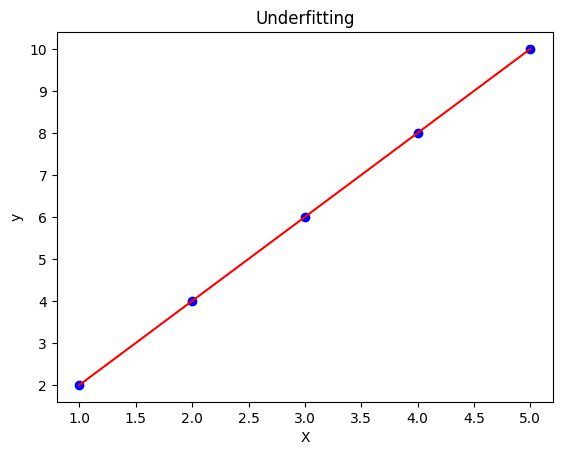

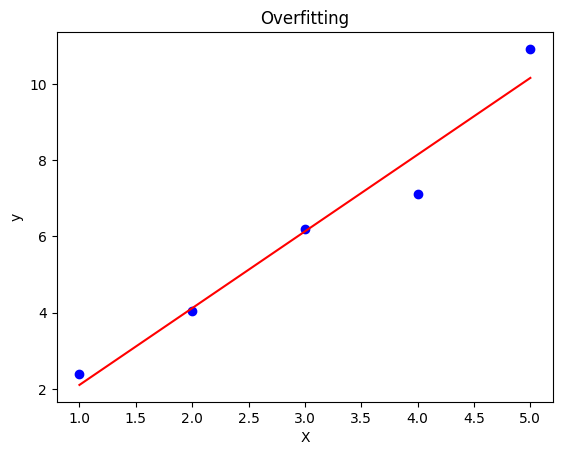

In [14]:
#Task - 7
#Overfitting and underfittig
#very simnple configuration for underfitting
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#Building the model with underfitting
#for gthat I am using the sample arrays with linear regression
X_underfit = np.array([[1], [2], [3], [4], [5]])
y_underfit = np.array([2, 4, 6, 8, 10])  
model_underfit = LinearRegression()
model_underfit.fit(X_underfit, y_underfit)
y_pred_underfit = model_underfit.predict(X_underfit)
mse_underfit = mean_squared_error(y_underfit, y_pred_underfit)
r2_underfit = r2_score(y_underfit, y_pred_underfit)
print("Underfitting - Mean Squared Error:", mse_underfit)
print("Underfitting - R2 Score:", r2_underfit)
#Now I am generating the synthetic data for overfitting
X_overfit = np.array([[1], [2], [3], [4], [5]])
y_overfit = np.array([2, 4, 6, 8, 10])  # Linear relationship
# Adding noise to the data to create overfitting
y_overfit_noisy = y_overfit + np.random.normal(0, 1, size=y_overfit.shape)
model_overfit = LinearRegression()
model_overfit.fit(X_overfit, y_overfit_noisy)
y_pred_overfit = model_overfit.predict(X_overfit)
mse_overfit = mean_squared_error(y_overfit_noisy, y_pred_overfit)
r2_overfit = r2_score(y_overfit_noisy, y_pred_overfit)
print("Overfitting - Mean Squared Error:", mse_overfit)
print("Overfitting - R2 Score:", r2_overfit)
#Now I am plotting the graphs for underfitting and overfitting
plt.scatter(X_underfit, y_underfit, color='blue', label='Actual')
plt.plot(X_underfit, y_pred_underfit, color='red', label='Predicted')
plt.title('Underfitting')
plt.xlabel('X')
plt.ylabel('y')
plt.show()
# Overfitting plot
plt.scatter(X_overfit, y_overfit_noisy, color='blue', label='Actual')
plt.plot(X_overfit, y_pred_overfit, color='red', label='Predicted')
plt.title('Overfitting')
plt.xlabel('X')
plt.ylabel('y')
plt.show()


Task - 8
Bias:
    1. The error caused by overly simple assumptions in the learning algorithm.
    2.Example: Fitting a straight line to data that actually follows a curve.
Varience:
    1. Variance refers to how sensitive a model is to small changes in the training data.
    2. Example: A very complex model that memorizes the dataset.
Relation Between Underfitting vs Overfitting
    Underfitting
        High bias, low variance
        Model is too simple
        Poor performance on both training and test data
    Overfitting
        Low bias, high variance
        Model is too complex
        Excellent training performance, poor generalization
reducing techniques for overfitting
    Simplify the model
\   Increase training data
